In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import ast
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score, KFold
from shapely.geometry import LineString, Point
from tqdm import tqdm
from itertools import combinations
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor, early_stopping
import shap
from scipy.stats import zscore
from scipy.spatial import cKDTree
import os
import fiona
import random
from geopy.distance import geodesic

/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.UInt64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)


In [2]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
caserne = gpd.read_file("../data/caserne/2024_06_21_CIS.shp")
compagnies = gpd.read_file("../data/caserne/2024_06_21_Compagnies.shp")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")
meteo_doubs = pd.read_csv("../data/meteo/meteostat_doubs.csv")
doubs_voisins = pd.read_csv("../data/data_train_test/doubs_tous_voisins.csv")

In [3]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print(f"Suppression de {len(to_drop)} features corrélées: {to_drop}")

    return X.drop(columns=to_drop)


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [4]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

In [5]:
doubs_data = doubs_data.merge(firepoint, on='hex_id', how='left')

threshold = 0.7 * len(doubs_data)
doubs_data.dropna(axis=1, thresh=threshold, inplace=True)

doubs_data.dropna(inplace=True)

In [6]:
caserne['compagnie'] = caserne['compagnie'].replace('Maîche', 'Maiche')

caserne = caserne.to_crs(epsg=4326)
caserne["lon"] = caserne.geometry.x
caserne["lat"] = caserne.geometry.y
compagnies = compagnies.to_crs(epsg=4326)

caserne = caserne.merge(compagnies[['id', 'nom']], left_on='compagnie', right_on='nom', how='left')

caserne = caserne.rename(columns={'id': 'id_compagnies'})

if 'nom' in caserne.columns:
    caserne = caserne.drop(columns=['nom'])

none_count = caserne['id_compagnies'].isna().sum()
print(f"Nombre de casernes sans id_compagnies : {none_count}")

print(caserne[['compagnie', 'id_compagnies']].head())

if 'nom_y' in caserne.columns:
    caserne = caserne.drop(columns=['nom_y'])

Nombre de casernes sans id_compagnies : 0
         compagnie  id_compagnies
0         Besançon            1.0
1  Baume-les-Dames            2.0
2      Montbéliard            6.0
3       Pontarlier            4.0
4      Montbéliard            6.0


In [7]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
compagnies = gpd.GeoDataFrame(compagnies, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
compagnies = compagnies.to_crs(epsg=4326)

doubs_data['id_compagnies'] = None

for idx, hexagone in doubs_data.iterrows():
    intersecting_companies = compagnies[compagnies.intersects(hexagone['geometry'])]

    if len(intersecting_companies) == 1:
        doubs_data.at[idx, 'id_compagnies'] = intersecting_companies.iloc[0]['id']
    elif len(intersecting_companies) > 1:
        max_area = 0
        best_company_id = None
        for _, company in intersecting_companies.iterrows():
            intersection = hexagone['geometry'].intersection(company['geometry'])
            area = intersection.area
            if area > max_area:
                max_area = area
                best_company_id = company['id']

        doubs_data.at[idx, 'id_compagnies'] = best_company_id

print(doubs_data[['hex_id', 'id_compagnies']].head())

            hex_id id_compagnies
0  871f820aaffffff           4.0
1  871f82d61ffffff          12.0
2  871f82d61ffffff          12.0
3  871f82d4dffffff           1.0
4  871f82700ffffff           5.0


In [8]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
caserne = caserne.to_crs(epsg=4326)

doubs_data['id_caserne'] = None
doubs_data['distance'] = None

for idx, hexagone in doubs_data.iterrows():
    casernes_same_company = caserne[caserne['id_compagnies'] == hexagone['id_compagnies']]

    if casernes_same_company.empty:
        continue

    distances = casernes_same_company.geometry.distance(hexagone['geometry'])

    nearest_caserne_idx = distances.idxmin()
    nearest_caserne = casernes_same_company.loc[nearest_caserne_idx]

    doubs_data.at[idx, 'id_caserne'] = nearest_caserne['id_pg']
    doubs_data.at[idx, 'distance'] = distances.min()

print(doubs_data[['hex_id', 'id_compagnies', 'id_caserne', 'distance']].head())

Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



            hex_id id_compagnies id_caserne  distance
0  871f820aaffffff           4.0     840709       0.0
1  871f82d61ffffff          12.0     840704  0.005327
2  871f82d61ffffff          12.0     840704  0.005327
3  871f82d4dffffff           1.0     840698  0.039716
4  871f82700ffffff           5.0     840701  0.010387


In [9]:
doubs_data.head()

,hex_id,raison_sortie,date_debut,date_fin,label,year,date,departement,duree_minutes,geometry,...,crops,shrub,flooded,built,bare,snow,sinister,id_compagnies,id_caserne,distance
0,871f820aaffffff,NATURELS,2014-10-02 14:08:53,2014-10-02 19:54:25,1.0,2014.0,2014-10-02,departement-25-doubs,345.533333,"POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...",...,0.478770,1.713494,0.062996,3.112007,0.604763,0.0,1.0,4.0,840709,0.0
1,871f82d61ffffff,NATURELS,2014-10-03 19:33:59,2014-10-03 19:55:31,1.0,2014.0,2014-10-03,departement-25-doubs,21.533333,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",...,1.453672,17.671597,0.037922,6.345595,0.000000,0.0,2.0,12.0,840704,0.005327
2,871f82d61ffffff,NATURELS,2014-10-04 19:24:49,2014-10-04 19:59:02,1.0,2014.0,2014-10-04,departement-25-doubs,34.216667,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",...,1.453672,17.671597,0.037922,6.345595,0.000000,0.0,2.0,12.0,840704,0.005327
3,871f82d4dffffff,NATURELS,2014-10-04 20:10:43,2014-10-04 20:42:34,1.0,2014.0,2014-10-04,departement-25-doubs,31.850000,"POLYGON ((5.87805 47.22180, 5.88000 47.20981, ...",...,0.063147,1.780753,0.025259,10.204597,0.000000,0.0,6.0,1.0,840698,0.039716
4,871f82700ffffff,NATURELS,2014-10-05 12:57:52,2014-10-05 13:24:24,1.0,2014.0,2014-10-05,departement-25-doubs,26.533333,"POLYGON ((6.30249 46.75999, 6.30437 46.74791, ...",...,0.478288,0.138452,0.088106,11.164254,0.000000,0.0,2.0,5.0,840701,0.010387


In [10]:
doubs_data['date'] = pd.to_datetime(doubs_data['date'])

def get_saison(month):
    if month in [12, 1, 2]:
        return 'Hiver'
    elif month in [3, 4, 5]:
        return 'Printemps'
    elif month in [6, 7, 8]:
        return 'Été'
    else:
        return 'Automne'

doubs_data['saison'] = doubs_data['date'].dt.month.apply(get_saison)

doubs_data['saison_annee'] = doubs_data['saison'] + ' ' + doubs_data['date'].dt.year.astype(str)

print(doubs_data[['date', 'saison', 'saison_annee']].head())

        date   saison  saison_annee
0 2014-10-02  Automne  Automne 2014
1 2014-10-03  Automne  Automne 2014
2 2014-10-04  Automne  Automne 2014
3 2014-10-04  Automne  Automne 2014
4 2014-10-05  Automne  Automne 2014


In [11]:
cols_to_drop = [
    'raison_sortie', 'label', 'departement', 'duree',
    'index', 'longitude', 'latitude', 'sinister', 'id_caserne', 'date_debut', 'date_fin', 'year', 'scale0', 'hour', 'month', 'weekday', 'distance', 'saison'
]

doubs_data = doubs_data.drop(columns=[col for col in cols_to_drop if col in doubs_data.columns])

      z  Lower Bound  Upper Bound        MAE       RMSE        R2  \
0   2.0  -193.308183   365.771043  35.301036  49.568009  0.030354   
1   2.1  -207.285164   379.748023  37.570279  50.756412  0.041264   
2   2.2  -221.262145   393.725004  37.570279  50.756412  0.041264   
3   2.3  -235.239125   407.701985  37.456715  51.824335  0.063704   
4   2.4  -249.216106   421.678965  38.777120  55.530498  0.042433   
5   2.5  -263.193087   435.655946  37.191344  54.357449  0.082462   
6   2.6  -277.170067   449.632927  37.416691  53.991449 -0.016037   
7   2.7  -291.147048   463.609907  36.014943  52.960120  0.022409   
8   2.8  -305.124029   477.586888  36.578454  55.067346  0.026893   
9   2.9  -319.101009   491.563869  36.578454  55.067346  0.026893   
10  3.0  -333.077990   505.540849  37.234171  57.746589  0.023126   
11  3.1  -347.054971   519.517830  36.426815  56.146294  0.076518   
12  3.2  -361.031951   533.494811  37.683943  57.799374  0.021339   
13  3.3  -375.008932   547.471791 

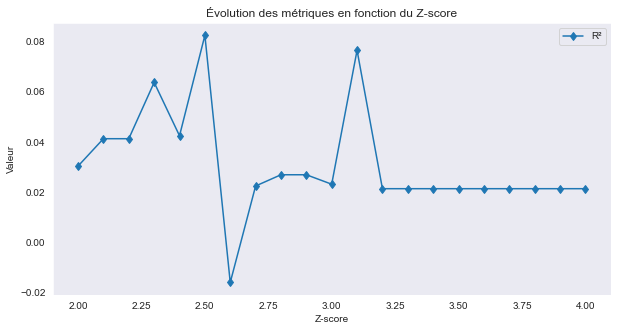

In [12]:
df = doubs_data.copy()

results = []

z_values = np.arange(2.0, 4.1, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    lower_bound = df_filtered['duree_minutes'].mean() - z * df_filtered['duree_minutes'].std()
    upper_bound = df_filtered['duree_minutes'].mean() + z * df_filtered['duree_minutes'].std()

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_percentage = (excluded_count / total_before) * 100

    hex_ids = df_filtered['hex_id'].unique()
    hex_train, hex_test = train_test_split(hex_ids, test_size=0.2, random_state=42)

    train_data = df_filtered[df_filtered['hex_id'].isin(hex_train)]
    test_data = df_filtered[df_filtered['hex_id'].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'id_compagnies', 'saison_annee']), train_data['duree_minutes']
    X_test, y_test = test_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'id_compagnies', 'saison_annee']), test_data['duree_minutes']

    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }

    model = train(params, dtrain, num_boost_round=100, evals=[(dtest, "Test")], early_stopping_rounds=10, verbose_eval=False)

    y_pred = model.predict(dtest)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({'z': z, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
                    'MAE': mae, 'RMSE': rmse, 'R2': r2,
                    'Excluded Count': excluded_count, 'Excluded Percentage': excluded_percentage})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(10, 5))
plt.plot(results_df['z'], results_df['R2'], label="R²", marker='d')
plt.xlabel("Z-score")
plt.ylabel("Valeur")
plt.title("Évolution des métriques en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

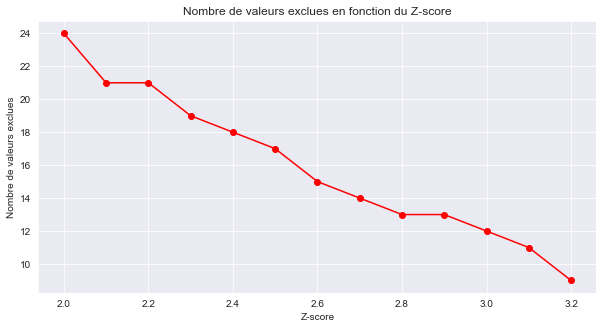

In [13]:
df = doubs_data.copy()

excluded_counts = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_counts.append(excluded_count)

plt.figure(figsize=(10, 5))
plt.plot(z_values, excluded_counts, label="Nombre de valeurs exclues", marker='o', color='red')
plt.xlabel("Z-score")
plt.ylabel("Nombre de valeurs exclues")
plt.title("Nombre de valeurs exclues en fonction du Z-score")
plt.grid(True)
plt.show()

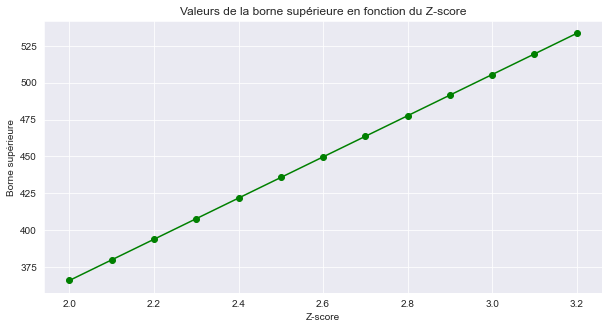

In [14]:
df = doubs_data.copy()

upper_bounds = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df['z_score'] = np.abs(zscore(df['duree_minutes']))

    upper_bound = df['duree_minutes'].mean() + z * df['duree_minutes'].std()

    upper_bounds.append(upper_bound)

plt.figure(figsize=(10, 5))
plt.plot(z_values, upper_bounds, label="Borne supérieure", marker='o', color='green')
plt.xlabel("Z-score")
plt.ylabel("Borne supérieure")
plt.title("Valeurs de la borne supérieure en fonction du Z-score")
plt.grid(True)
plt.show()

In [15]:
doubs_data['z_score'] = np.abs(zscore(doubs_data['duree_minutes']))

doubs_data_filtered = doubs_data[doubs_data['z_score'] <= 2.9].drop(columns=['z_score'])

values_removed = len(doubs_data) - len(doubs_data_filtered)
print(f"Nombre de valeurs supprimées : {values_removed}")
print(f"Pourcentage des données supprimées : {values_removed / len(doubs_data) * 100:.2f}%")

Nombre de valeurs supprimées : 13
Pourcentage des données supprimées : 0.49%


In [16]:
doubs_data_filtered['date'] = pd.to_datetime(doubs_data_filtered['date'])
meteo_doubs['creneau'] = pd.to_datetime(meteo_doubs['creneau'])

meteo_doubs['geometry'] = [Point(xy) for xy in zip(meteo_doubs['longitude'], meteo_doubs['latitude'])]
meteo_gdf = gpd.GeoDataFrame(meteo_doubs, geometry='geometry', crs="EPSG:4326")

doubs_data_filtered = doubs_data_filtered.to_crs("EPSG:32631")
meteo_gdf = meteo_gdf.to_crs("EPSG:32631")

def trouver_meteo_proche(row, meteo_gdf):
    meteo_jour = meteo_gdf[meteo_gdf['creneau'] == row['date']]
    if meteo_jour.empty:
        return pd.Series([np.nan] * len(meteo_gdf.columns), index=meteo_gdf.columns)

    centroid = row.geometry.centroid
    centroid_x, centroid_y = centroid.x, centroid.y

    tree = cKDTree(np.array(list(zip(meteo_jour.geometry.x, meteo_jour.geometry.y))))
    dist, idx = tree.query([centroid_x, centroid_y], k=1)

    return meteo_jour.iloc[idx]

meteo_associee = doubs_data_filtered.apply(lambda row: trouver_meteo_proche(row, meteo_gdf), axis=1)

meteo_associee = meteo_associee.rename(columns={'geometry': 'geometry_meteo'})

doubs_data_filtered = pd.concat([doubs_data_filtered.reset_index(drop=True), meteo_associee.reset_index(drop=True)], axis=1)

doubs_data_filtered = doubs_data_filtered.loc[:, ~doubs_data_filtered.columns.duplicated()]

In [17]:
colonnes_a_supprimer = ['geometry_meteo', 'year', 'longitude', 'latitude', 'index', 'creneau']
doubs_data_filtered = doubs_data_filtered.drop(columns=colonnes_a_supprimer)

In [18]:
doubs_data_filtered = doubs_data_filtered.dropna()

In [19]:
cols_a_conserver = ['hex_id', 'geometry', 'centroid', 'id_compagnies', 'saison_annee']

doubs_data_filtered = doubs_data_filtered.drop(columns=['date'])

doubs_data_moy = doubs_data_filtered.groupby(['hex_id', 'saison_annee'], as_index=False).mean(numeric_only=True)

doubs_data_conserve = doubs_data_filtered[cols_a_conserver].drop_duplicates(subset=['hex_id', 'saison_annee'])

doubs_data_final = pd.merge(doubs_data_moy, doubs_data_conserve, on=['hex_id', 'saison_annee'], how='left')

print(doubs_data_final.head())

            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff  Printemps 2019     163.133333      6.350198     47.477082   
1  871f80492ffffff  Printemps 2022      61.850000      6.350198     47.477082   
2  871f80492ffffff  Printemps 2023      72.083333      6.350198     47.477082   
3  871f80492ffffff        Été 2017     197.783333      6.350198     47.477082   
4  871f80492ffffff        Été 2019     168.250000      6.350198     47.477082   

       NDVI      NDMI      NDBI     NDSI      NDWI  ...        bui        fwi  \
0  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  35.098101  20.429792   
1  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...   9.748193   4.066704   
2  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  30.969181  11.517529   
3  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  30.499293  11.928195   
4  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  78.161184  21.688291   

   daily_severity_rating  

In [20]:
duree_stats = doubs_data_filtered.groupby(['hex_id', 'saison_annee'])['duree_minutes'].agg(
    duree_minutes_max='max',
    duree_minutes_med='median'
).reset_index()

doubs_data_final = pd.merge(doubs_data_final, duree_stats, on=['hex_id', 'saison_annee'], how='left')

print(doubs_data_final.head())

            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff  Printemps 2019     163.133333      6.350198     47.477082   
1  871f80492ffffff  Printemps 2022      61.850000      6.350198     47.477082   
2  871f80492ffffff  Printemps 2023      72.083333      6.350198     47.477082   
3  871f80492ffffff        Été 2017     197.783333      6.350198     47.477082   
4  871f80492ffffff        Été 2019     168.250000      6.350198     47.477082   

       NDVI      NDMI      NDBI     NDSI      NDWI  ...  \
0  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...   
1  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...   
2  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...   
3  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...   
4  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...   

   daily_severity_rating     nesterov  munger       kbdi  angstroem  \
0               5.671998  3519.020169   112.5   2.491277       3.06   
1               

In [21]:
stats_compagnies = (
    doubs_data_final.groupby("id_compagnies")["duree_minutes"]
    .agg(
        moyenne="mean",
        médiane="median",
        minimum="min",
        maximum="max",
        écart_type="std",
        Q1=lambda x: np.percentile(x, 25),
        Q3=lambda x: np.percentile(x, 75),
    )
    .reset_index()
)

In [22]:
doubs_data_final = doubs_data_final.merge(stats_compagnies, on="id_compagnies", how="left")

In [23]:
doubs_data_final.head()

,hex_id,saison_annee,duree_minutes,centroid_lon,centroid_lat,NDVI,NDMI,NDBI,NDSI,NDWI,...,id_compagnies,duree_minutes_max,duree_minutes_med,moyenne,médiane,minimum,maximum,écart_type,Q1,Q3
0,871f80492ffffff,Printemps 2019,163.133333,6.350198,47.477082,0.720443,0.145452,-0.145452,-0.59362,-0.672639,...,2.0,163.133333,163.133333,85.609959,72.083333,2.85,276.766667,47.482618,49.779167,107.208333
1,871f80492ffffff,Printemps 2022,61.850000,6.350198,47.477082,0.720443,0.145452,-0.145452,-0.59362,-0.672639,...,2.0,61.850000,61.850000,85.609959,72.083333,2.85,276.766667,47.482618,49.779167,107.208333
2,871f80492ffffff,Printemps 2023,72.083333,6.350198,47.477082,0.720443,0.145452,-0.145452,-0.59362,-0.672639,...,2.0,72.083333,72.083333,85.609959,72.083333,2.85,276.766667,47.482618,49.779167,107.208333
3,871f80492ffffff,Été 2017,197.783333,6.350198,47.477082,0.720443,0.145452,-0.145452,-0.59362,-0.672639,...,2.0,197.783333,197.783333,85.609959,72.083333,2.85,276.766667,47.482618,49.779167,107.208333
4,871f80492ffffff,Été 2019,168.250000,6.350198,47.477082,0.720443,0.145452,-0.145452,-0.59362,-0.672639,...,2.0,168.250000,168.250000,85.609959,72.083333,2.85,276.766667,47.482618,49.779167,107.208333


In [24]:
ordre_saisons = {'Hiver': 1, 'Printemps': 2, 'Été': 3, 'Automne': 4}

doubs_data_final[['Saison', 'Annee']] = doubs_data_final['saison_annee'].str.split(' ', expand=True)
doubs_data_final['Annee'] = doubs_data_final['Annee'].astype(int)
doubs_data_final['Saison_ordre'] = doubs_data_final['Saison'].map(ordre_saisons)

doubs_data_final = doubs_data_final.sort_values(by=['hex_id', 'Annee', 'Saison_ordre'])

doubs_data_final['moyenne_duree_hex_id'] = (
    doubs_data_final.groupby('hex_id')['duree_minutes']
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

doubs_data_final['moyenne_duree_hex_id'].fillna(0, inplace=True)

doubs_data_final.drop(columns=['Saison', 'Annee', 'Saison_ordre'], inplace=True)

In [25]:
test_size = 0.2
random_state = 42
hex_ids = doubs_data_final["hex_id"].unique()
splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx, test_idx = next(splitter.split(hex_ids, groups=hex_ids))
train_hex = hex_ids[train_idx]
test_hex = hex_ids[test_idx]
doubs_train = doubs_data_final[doubs_data_final["hex_id"].isin(train_hex)]
doubs_test = doubs_data_final[doubs_data_final["hex_id"].isin(test_hex)]
print(f"Taille du train : {doubs_train.shape[0]} lignes")
print(f"Taille du test : {doubs_test.shape[0]} lignes")

Taille du train : 1380 lignes
Taille du test : 359 lignes


In [26]:
common_hex = set(doubs_train["hex_id"]).intersection(set(doubs_test["hex_id"]))
if common_hex:
    print(f"Problème : {len(common_hex)} hex_id sont présents dans les deux datasets.")
else:
    print("Vérification réussie : Aucun hex_id en commun entre train et test.")

Vérification réussie : Aucun hex_id en commun entre train et test.


In [27]:
doubs_train = doubs_train.merge(doubs_voisins[['hex_id', 'hex_voisins']], on='hex_id', how='left')

doubs_test = doubs_test.merge(doubs_voisins[['hex_id', 'hex_voisins']], on='hex_id', how='left')

In [28]:
doubs_train['hex_voisins'] = doubs_train['hex_voisins'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
doubs_test['hex_voisins'] = doubs_test['hex_voisins'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

print(doubs_train['hex_voisins'].head())
print(doubs_test['hex_voisins'].head())

0    [871f8286cffffff, 871f80493ffffff, 871f82860ff...
1    [871f8286cffffff, 871f80493ffffff, 871f82860ff...
2    [871f8286cffffff, 871f80493ffffff, 871f82860ff...
3    [871f8286cffffff, 871f80493ffffff, 871f82860ff...
4    [871f8286cffffff, 871f80493ffffff, 871f82860ff...
Name: hex_voisins, dtype: object
0    [871f8049effffff, 871f8049cffffff, 871f80493ff...
1    [871f804d2ffffff, 871f804d1ffffff, 871f804deff...
2    [871f804d8ffffff, 871f804ceffffff, 871f82b60ff...
3    [871f804d8ffffff, 871f804d1ffffff, 871f82b2dff...
4    [871f8079affffff, 871f806b4ffffff, 871f806b5ff...
Name: hex_voisins, dtype: object


In [29]:
def calculer_statistiques(row, train_data):
    hex_cible = row['hex_id']
    saison_actuelle = row['saison_annee']

    hex_voisins = row['hex_voisins']

    hex_ids_a_prendre = [hex_cible] + hex_voisins
    data_filtree = train_data[train_data['hex_id'].isin(hex_ids_a_prendre)]

    data_filtree = data_filtree[data_filtree['saison_annee'] < saison_actuelle]

    if data_filtree.empty:
        return pd.Series([np.nan] * 7,
                         index=['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
                                'duree_min', 'duree_max', 'duree_q1', 'duree_q3'])

    duree_moyenne = data_filtree['duree_minutes'].mean()
    duree_mediane = data_filtree['duree_minutes'].median()
    duree_ecart_type = data_filtree['duree_minutes'].std()
    duree_min = data_filtree['duree_minutes'].min()
    duree_max = data_filtree['duree_minutes'].max()
    duree_q1 = data_filtree['duree_minutes'].quantile(0.25)
    duree_q3 = data_filtree['duree_minutes'].quantile(0.75)

    return pd.Series([duree_moyenne, duree_mediane, duree_ecart_type,
                      duree_min, duree_max, duree_q1, duree_q3],
                     index=['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
                            'duree_min', 'duree_max', 'duree_q1', 'duree_q3'])

doubs_train[['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
             'duree_min', 'duree_max', 'duree_q1', 'duree_q3']] = doubs_train.apply(
    lambda row: calculer_statistiques(row, doubs_data_final), axis=1)

doubs_test[['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
            'duree_min', 'duree_max', 'duree_q1', 'duree_q3']] = doubs_test.apply(
    lambda row: calculer_statistiques(row, doubs_data_final), axis=1)

print(doubs_train.head())
print(doubs_test.head())

            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff        Été 2017     197.783333      6.350198     47.477082   
1  871f80492ffffff  Printemps 2019     163.133333      6.350198     47.477082   
2  871f80492ffffff        Été 2019     168.250000      6.350198     47.477082   
3  871f80492ffffff  Printemps 2022      61.850000      6.350198     47.477082   
4  871f80492ffffff  Printemps 2023      72.083333      6.350198     47.477082   

       NDVI      NDMI      NDBI     NDSI      NDWI  ...          Q3  \
0  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   
1  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   
2  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   
3  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   
4  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   

   moyenne_duree_hex_id                                        hex_voisins  \
0       

In [30]:
colonnes_statistiques = ['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
                         'duree_min', 'duree_max', 'duree_q1', 'duree_q3']

doubs_train[colonnes_statistiques] = doubs_train[colonnes_statistiques].fillna(0)
doubs_test[colonnes_statistiques] = doubs_test[colonnes_statistiques].fillna(0)

print(doubs_train.head())
print(doubs_test.head())

            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff        Été 2017     197.783333      6.350198     47.477082   
1  871f80492ffffff  Printemps 2019     163.133333      6.350198     47.477082   
2  871f80492ffffff        Été 2019     168.250000      6.350198     47.477082   
3  871f80492ffffff  Printemps 2022      61.850000      6.350198     47.477082   
4  871f80492ffffff  Printemps 2023      72.083333      6.350198     47.477082   

       NDVI      NDMI      NDBI     NDSI      NDWI  ...          Q3  \
0  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   
1  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   
2  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   
3  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   
4  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  107.208333   

   moyenne_duree_hex_id                                        hex_voisins  \
0       

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features = [col for col in doubs_train.columns if col not in ['duree_minutes', 'duree_minutes_max', 'duree_minutes_med','hex_id', 'geometry', 'centroid', 'saison_annee','hex_voisins', 'id_compagnies']]

X_train = doubs_train[features]
y_train = doubs_train[['duree_minutes', 'duree_minutes_max', 'duree_minutes_med']]

X_test = doubs_test[features]
y_test = doubs_test[['duree_minutes', 'duree_minutes_max', 'duree_minutes_med']]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))

rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)

for i, target in enumerate(['duree_minutes', 'duree_minutes_max', 'duree_minutes_med']):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])

    print(f"Résultats pour {target} :")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}")
    print("-" * 40)

Résultats pour duree_minutes :
  MAE  : 36.3816
  MSE  : 2549.6491
  RMSE : 50.49
  R²   : 0.0778
----------------------------------------
Résultats pour duree_minutes_max :
  MAE  : 40.1461
  MSE  : 3357.4980
  RMSE : 57.94
  R²   : 0.0320
----------------------------------------
Résultats pour duree_minutes_med :
  MAE  : 35.9211
  MSE  : 2598.5809
  RMSE : 50.98
  R²   : 0.0921
----------------------------------------


In [32]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

results = {}

features = [col for col in doubs_train.columns if col not in ['duree_minutes', 'duree_minutes_max', 'duree_minutes_med','hex_id', 'geometry', 'centroid', 'saison_annee','hex_voisins', 'id_compagnies']]
X_train = doubs_train[features]
y_train = doubs_train[['duree_minutes', 'duree_minutes_max', 'duree_minutes_med']]
X_test = doubs_test[features]
y_test = doubs_test[['duree_minutes', 'duree_minutes_max', 'duree_minutes_med']]

for scaler_name, scaler in scalers.items():
    print(f"\n🔹 Test avec {scaler_name}...")

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    rf_model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))

    rf_model.fit(X_train_scaled, y_train)

    y_pred = rf_model.predict(X_test_scaled)

    metrics_results = {}
    for i, target in enumerate(['duree_minutes', 'duree_minutes_max', 'duree_minutes_med']):
        y_true_target = y_test.iloc[:, i]
        y_pred_target = y_pred[:, i]

        mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
        mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])

        metrics_results[target] = {
            "MAE": round(mae, 4),
            "MSE": round(mse, 4),
            "RMSE": round(rmse, 2),
            "R²": round(r2, 4)
        }

    results[scaler_name] = metrics_results

for scaler_name, metrics_dict in results.items():
    print(f"\n🔹 Résultats avec {scaler_name}:")
    for target, metrics in metrics_dict.items():
        print(f"  {target}:")
        print(f"    MAE  : {metrics['MAE']:.4f}")
        print(f"    MSE  : {metrics['MSE']:.4f}")
        print(f"    RMSE : {metrics['RMSE']:.2f}")
        print(f"    R²   : {metrics['R²']:.4f}")


🔹 Test avec StandardScaler...

🔹 Test avec MinMaxScaler...

🔹 Test avec RobustScaler...

🔹 Résultats avec StandardScaler:
  duree_minutes:
    MAE  : 36.3816
    MSE  : 2549.6491
    RMSE : 50.49
    R²   : 0.0778
  duree_minutes_max:
    MAE  : 40.1461
    MSE  : 3357.4980
    RMSE : 57.94
    R²   : 0.0320
  duree_minutes_med:
    MAE  : 35.9211
    MSE  : 2598.5809
    RMSE : 50.98
    R²   : 0.0921

🔹 Résultats avec MinMaxScaler:
  duree_minutes:
    MAE  : 36.6950
    MSE  : 2589.5779
    RMSE : 50.89
    R²   : 0.0633
  duree_minutes_max:
    MAE  : 40.2293
    MSE  : 3366.9286
    RMSE : 58.03
    R²   : 0.0293
  duree_minutes_med:
    MAE  : 36.1809
    MSE  : 2626.7444
    RMSE : 51.25
    R²   : 0.0822

🔹 Résultats avec RobustScaler:
  duree_minutes:
    MAE  : 36.5079
    MSE  : 2577.5852
    RMSE : 50.77
    R²   : 0.0677
  duree_minutes_max:
    MAE  : 40.5666
    MSE  : 3408.5325
    RMSE : 58.38
    R²   : 0.0173
  duree_minutes_med:
    MAE  : 36.2707
    MSE  : 2633.0

In [33]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

rf_model = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))

rf_model.fit(X_train_scaled, y_train_log)

y_pred_log = rf_model.predict(X_test_scaled)

y_pred = np.expm1(y_pred_log)

results = {}
for i, target in enumerate(['duree_minutes', 'duree_minutes_max', 'duree_minutes_med']):
    mae = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    mse = mean_squared_error(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])

    results[target] = {
        "MAE": round(mae, 4),
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 2),
        "R²": round(r2, 4)
    }

print("\n🔹 Résultats avec StandardScaler + Transformation Logarithmique:")
for target, metrics in results.items():
    print(f"  {target}:")
    print(f"    MAE  : {metrics['MAE']:.4f}")
    print(f"    MSE  : {metrics['MSE']:.4f}")
    print(f"    RMSE : {metrics['RMSE']:.2f}")
    print(f"    R²   : {metrics['R²']:.4f}")



🔹 Résultats avec StandardScaler + Transformation Logarithmique:
  duree_minutes:
    MAE  : 32.5394
    MSE  : 2506.8459
    RMSE : 50.07
    R²   : 0.0933
  duree_minutes_max:
    MAE  : 36.0234
    MSE  : 3316.7566
    RMSE : 57.59
    R²   : 0.0437
  duree_minutes_med:
    MAE  : 32.1759
    MSE  : 2534.2300
    RMSE : 50.34
    R²   : 0.1146


In [35]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_med = y_train['duree_minutes_med']
y_test_med = y_test['duree_minutes_med']

rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [20, 25, 30, 35, 50],
    'min_samples_split': [2, 3, 4, 6, 10],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', 0.6, 0.8],
}

grid_search = GridSearchCV(
    estimator=rf_model, param_grid=param_grid,
    cv=5, n_jobs=-1, verbose=1, scoring='r2'
)
grid_search.fit(X_train_scaled, y_train_med)

best_rf_model = grid_search.best_estimator_

y_pred_med = best_rf_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test_med, y_pred_med)
mse = mean_squared_error(y_test_med, y_pred_med)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_med, y_pred_med)

print("\n🚀 Résultats optimisés avec Random Forest :")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print("\nMeilleurs hyperparamètres :")
print(grid_search.best_params_)

Fitting 5 folds for each of 800 candidates, totalling 4000 fits

🚀 Résultats optimisés avec Random Forest :
MAE  : 34.0254
MSE  : 2455.1584
RMSE : 49.55
R²   : 0.1422

Meilleurs hyperparamètres :
{'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 300}


In [ ]:
"""🚀 Résultats optimisés avec Random Forest :
MAE  : 34.0254
MSE  : 2455.1584
RMSE : 49.55
R²   : 0.1422

Meilleurs hyperparamètres :
{'max_depth': 25, 'max_features': 'log2', 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 300}"""